In [12]:
##### Creates maps of agricultural capital and labor intensities 
# Side-by-side of pixel intensities and country intensities 

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
import matplotlib.patches as mpatches

In [14]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

# National data
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_intensity_side_by_side"

In [15]:
### Data prep

# align rasters to capital grid
crs = capital_intensity.rio.crs

labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)
country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)

### Prep national intensities 

# merge to geo 
country_boundaries = country_boundaries.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='left')
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

In [16]:
values = capital_intensity.values.flatten()

# drop NaNs (rasters typically have nodata pixels, e.g. ocean/non-agricultural areas)
values_clean = values[~np.isnan(values)]

# further restrict to values strictly above 0
values_clean = values_clean[values_clean > 0]

print(f"Total pixels: {len(values)}")
print(f"Valid (non-NaN, >0) pixels: {len(values_clean)}")

# pull every 10th percentile: 10, 20, 30, ..., 100
percentiles = np.arange(10, 101, 10)
percentile_values = np.percentile(values_clean, percentiles)

for p, v in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {v:.2f}")

Total pixels: 6377176
Valid (non-NaN, >0) pixels: 1175488
10th percentile: 137.83
20th percentile: 253.30
30th percentile: 375.87
40th percentile: 526.92
50th percentile: 737.28
60th percentile: 1004.54
70th percentile: 1332.54
80th percentile: 1862.34
90th percentile: 2813.06
100th percentile: 313052.53


#### Map intensity rasters

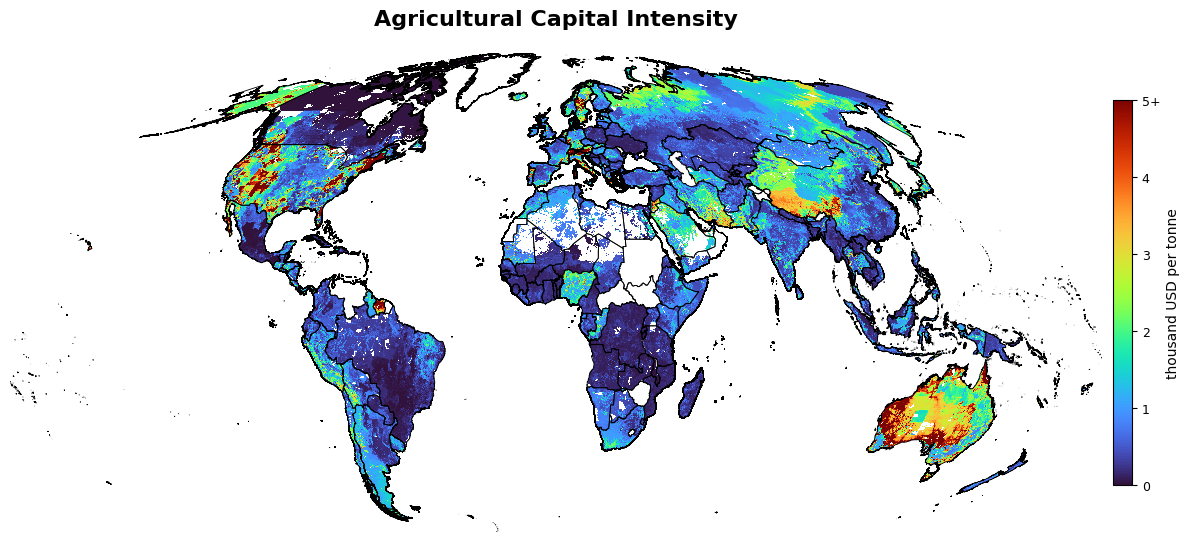

In [4]:
##### Produce global map of capital intensity

# Prepare raster
value_plot = capital_intensity.squeeze()
name = 'capital_intensity'

bounds = [0, 1000, 2000, 3000, 4000, 5000] 
labels = ['0', '1', '2', '3', '4', '5+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=5000,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("thousand USD per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

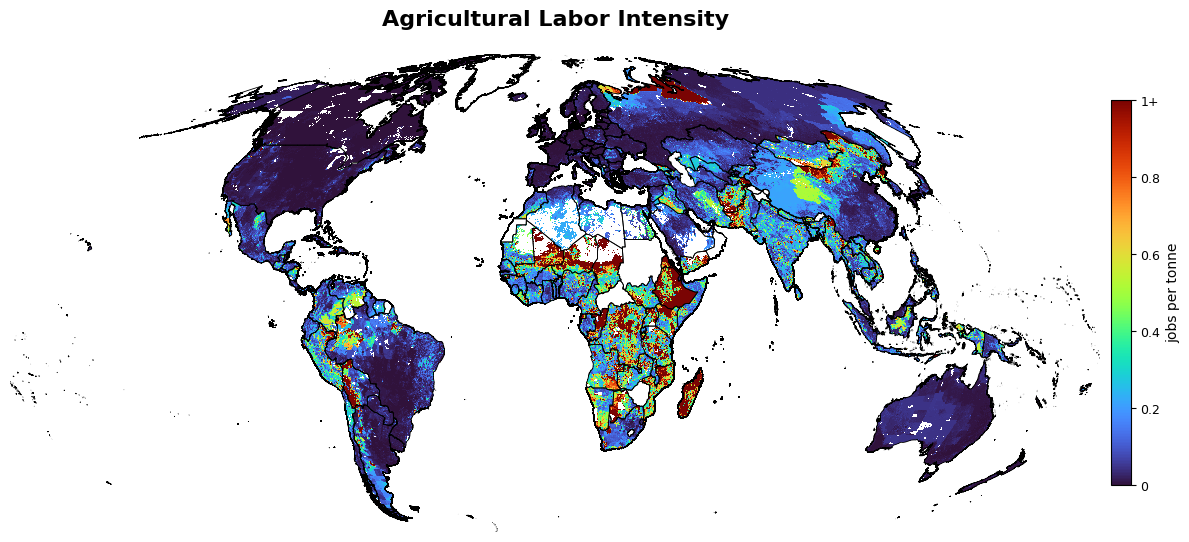

In [17]:
##### Produce global map of labor intensity

# Prepare raster
value_plot = labor_intensity.squeeze()
name = 'labor_intensity'

bounds = [0, 0.2, 0.4, 0.6, 0.8, 1] 
labels = ['0', '0.2', '0.4', '0.6', '0.8', '1+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=1,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("jobs per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

#### Map intensities (country/raster side-by-side)

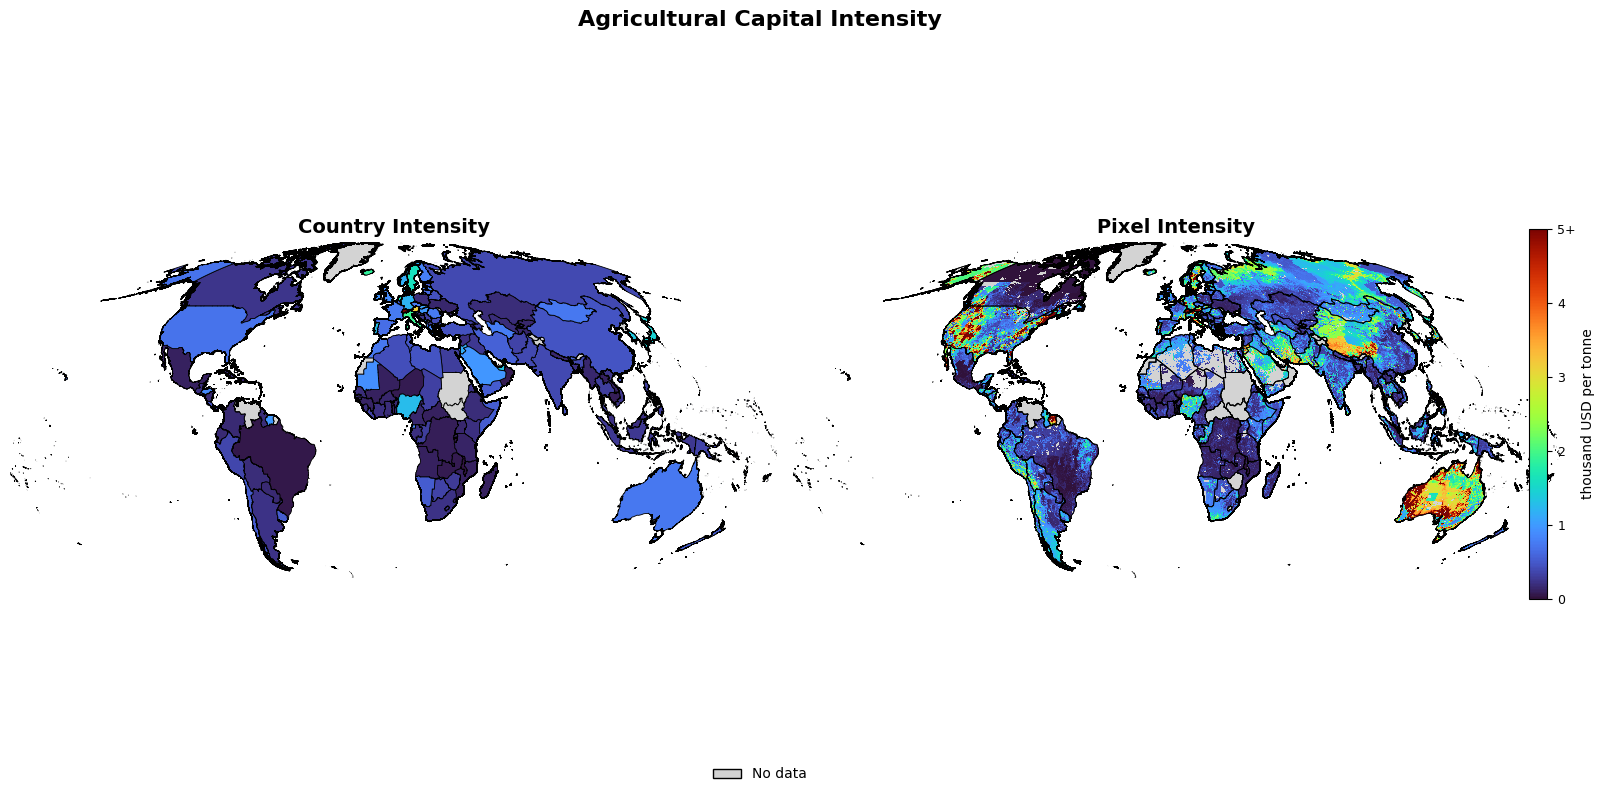

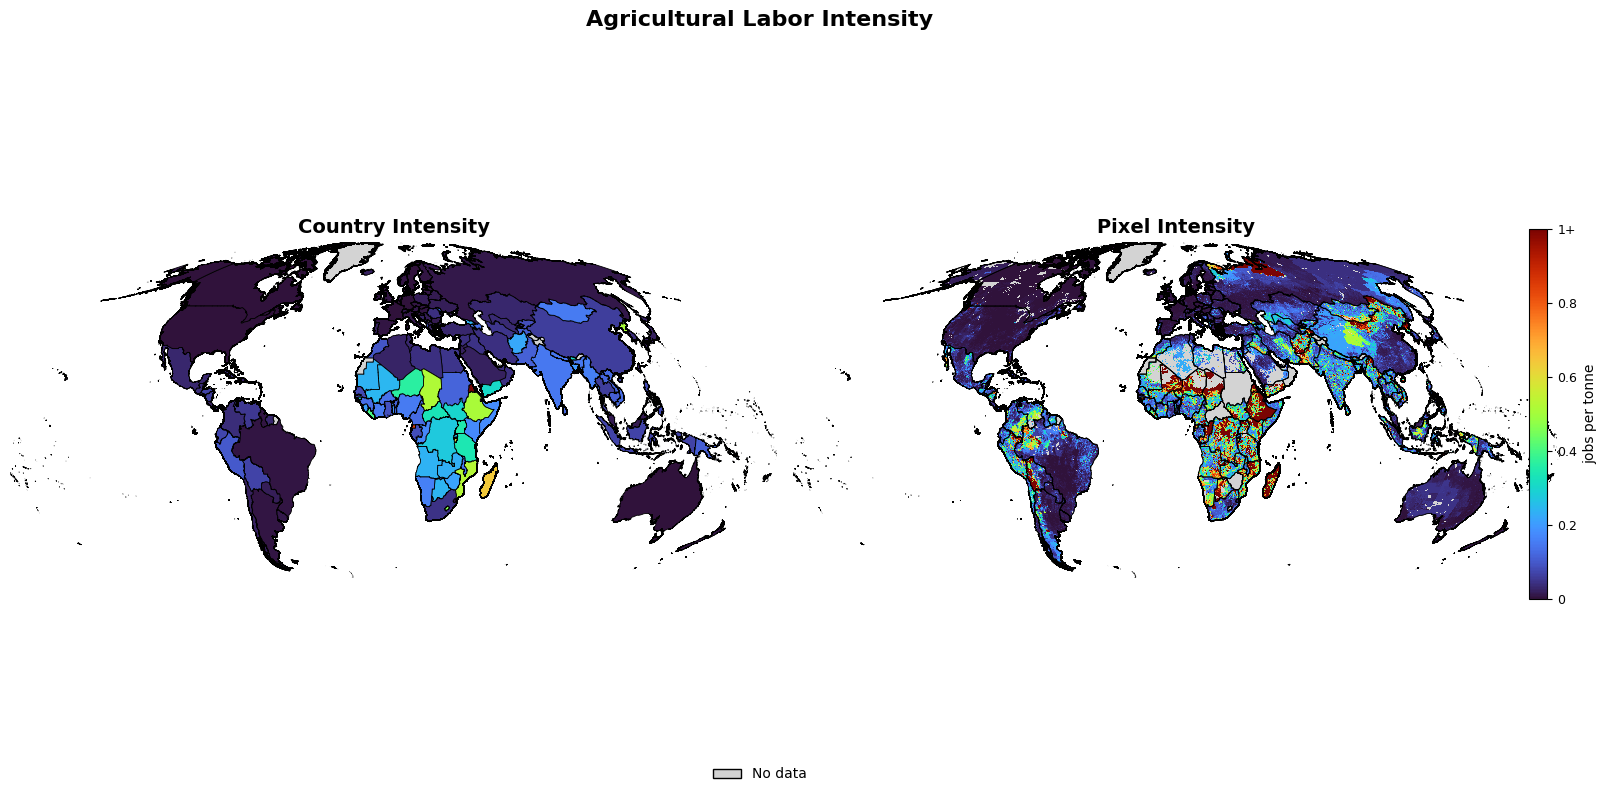

In [21]:
##### Side-by-side raster vs. country intensity maps

def plot_intensity_side_by_side(
    raster, country_gdf, value_col, bounds, labels, vmin, vmax,
    title, cbar_label, out_path, cmap="turbo", missing_color="lightgrey"
):
    """
    Plot country-level choropleth intensity (left) alongside pixel-level
    raster intensity (right), on the same color scale. Areas/countries
    with missing data are shown in light grey on both panels, with a
    single shared colorbar and a 'No data' legend entry.
    """
    value_plot = raster.squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    minx, miny, maxx, maxy = country_gdf.total_bounds

    # --- Left panel: country-level choropleth ---
    ax0 = axes[0]

    has_data = country_gdf[country_gdf[value_col].notna()]
    no_data = country_gdf[country_gdf[value_col].isna()]

    no_data.plot(ax=ax0, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)

    has_data.plot(
        ax=ax0, column=value_col, cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolor="black", linewidth=0.6, zorder=2
    )

    ax0.set_xlim(minx, maxx)
    ax0.set_ylim(miny, maxy)
    ax0.set_axis_off()
    ax0.set_title("Country Intensity", fontsize=14, weight="bold")

    # --- Right panel: pixel intensity ---
    ax1 = axes[1]

    # grey basemap first, so nodata pixels show through as missing
    country_gdf.plot(ax=ax1, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)

    im = value_plot.plot(
        ax=ax1, cmap=cmap, vmin=vmin, vmax=vmax,
        add_colorbar=False, add_labels=False, zorder=2
    )

    country_gdf.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

    ax1.set_xlim(minx, maxx)
    ax1.set_ylim(miny, maxy)
    ax1.set_axis_off()
    ax1.set_title("Pixel Intensity", fontsize=14, weight="bold")

    fig.suptitle(title, fontsize=16, weight="bold", y=1.0)

    # --- Shared colorbar (built off the raster image, same vmin/vmax as choropleth) ---
    cbar = fig.colorbar(
        im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, shrink=0.6
    )
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_ticks(bounds)
    cbar.set_ticklabels(labels)

    # --- Missing-data legend entry ---
    missing_patch = mpatches.Patch(facecolor=missing_color, edgecolor="black", label="No data")
    fig.legend(handles=[missing_patch], loc="lower center", bbox_to_anchor=(0.5, 0.02), frameon=False)

    fig.subplots_adjust(top=0.92, bottom=0.08, wspace=0.02)
    fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()


# --- Capital intensity ---
plot_intensity_side_by_side(
    raster=capital_intensity,
    country_gdf=country_boundaries,
    value_col="capital_intensity_USD_per_tonne",
    bounds=[0, 1000, 2000, 3000, 4000, 5000],
    labels=['0', '1', '2', '3', '4', '5+'],
    vmin=0, vmax=5000,
    title="Agricultural Capital Intensity",
    cbar_label="thousand USD per tonne",
    out_path=f"{fd}/capital_intensity_side_by_side.png",
)

# --- Labor intensity ---
plot_intensity_side_by_side(
    raster=labor_intensity,
    country_gdf=country_boundaries,
    value_col="labor_intensity_jobs_per_tonne",
    bounds=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=['0', '0.2', '0.4', '0.6', '0.8', '1+'],
    vmin=0, vmax=1,
    title="Agricultural Labor Intensity",
    cbar_label="jobs per tonne",
    out_path=f"{fd}/labor_intensity_side_by_side.png",
)